In [12]:
import drjit as dr
import xdesign as xd
import cupy as xp
import matplotlib.pyplot as plt
from pathlib import Path
import torch as th
import torch as th 
from drjit.cuda.ad import Array2f, Array1f, ArrayXf, Float, TensorXf
import numpy as np

device = th.device("cuda:0" if th.cuda.is_available() else "cpu")

In [13]:
import sys
sys.path.append("src")
import xrt_toolkit as xtk

In [14]:
def create_phantom(N_side):
    seed = 0
    np.random.seed(seed)
    p1 = xd.Foam(size_range=[0.1, 0.01], gap=0.025, porosity=0.5)
    phantom = xd.discrete_phantom(p1, N_side-5) * 10
    phantom = np.pad(phantom, 5)
    phantom = np.abs(phantom)
    return xp.array(phantom)

_x = create_phantom(100)
x_th = th.tensor(_x, device=device, dtype=th.float32)
v_shape = x_th.shape
n_angles = v_shape[0]
print(v_shape, x_th.min(), x_th.max())

torch.Size([105, 105]) tensor(0., device='cuda:0') tensor(10., device='cuda:0')


/home/runai-home/.local/lib/python3.11/site-packages/xdesign/phantom/phantom.py:375: RuntimeWarning: Reached termination criteria of 500 attempts before adding all of the circles.
  warnings.warn((


In [15]:
def set_operators_parallel_beam_dr(N_side, N_angle, N_offset, pitch, angles):
    angles = Float(angles)
    t_max = pitch * (N_side - 1) / 2 * dr.sqrt(2.0)
    t_offset = dr.linspace(Float, -t_max, t_max, N_offset)  
    A, T = dr.meshgrid(angles, t_offset, indexing='ij')  
    M = N_angle * N_offset
    A = dr.reshape(A, shape=(M,))
    T = dr.reshape(T, shape=(M,))
    c = dr.cos(A)
    s = dr.sin(A)
    
    n_spec = Array2f(c, s) 
    t_unit = Array2f(s, c) * Array2f(-1.0, 1.0)

    t_spec = t_unit * T + pitch * N_side / 2

    return t_spec, n_spec

In [16]:
import xrt_toolkit.util as xrtu

from xrt_toolkit.util.compat import (
    asarray as asarray,
)
from xrt_toolkit.util.dtype import (
    TranslateDType as TranslateDType,
)
from xrt_toolkit.util.mesh import (
    DetectorSpec as DetectorSpec,
    UniformSpec as UniformSpec,
)
from xrt_toolkit.util.misc import (
    broadcast_seq as broadcast_seq,
)
from xrt_toolkit.util.type_traits import (
    int_array_t as int_array_t,
    uint_array_t as uint_array_t,
    float_array_t as float_array_t,
    float_matrix_t as float_matrix_t,
)

import typing as typ
ArrayNNfT = typ.TypeVar("ArrayNNfT", bound=dr.AnyArray)
FloatT = typ.TypeVar("FloatT", bound=dr.AnyArray)
RaySpecT = tuple[ArrayNNfT, ArrayNNfT, UniformSpec]


# @dr.syntax
def cone_beam(
    sod: float,
    sdd: float,
    angles: FloatT,
    detector_spec: DetectorSpec,
    delta = (0.0,0.0),
) -> RaySpecT:
   
    assert 0 < sod < sdd

    Float = type(angles)
    Matrix2 = float_matrix_t(Float, 2)
    Matrix3 = float_matrix_t(Float, 3)

    R = Matrix3(
        *(dr.cos(angles), -dr.sin(angles), 0),
        *(dr.sin(angles), dr.cos(angles), 0),
        *(0, 0, 1),
    )

    ray_t_spec = R @ Matrix3(
        *(0, 0, -sod),
        *(0, 0, 0),
        *(0, 0, 0),
    )
    ray_n_spec = R @ Matrix3(
        *(0, 0, sdd),
        *(1, 0, 0),
        *(0, 1, 0),
    )

    D = detector_spec.ndim + 1
    if D == 2:
        select = lambda mat3: Matrix2(
            *(mat3[0, 0], mat3[0, 2]),
            *(mat3[1, 0], mat3[1, 2]),
        )
        ray_t_spec = select(ray_t_spec)
        ray_n_spec = select(ray_n_spec)

    ll_center = tuple(
        (cs - s) / 2
        for (cs, s) in zip(
            detector_spec.cell_size,
            detector_spec.size,
        )
    )

    ray_u_spec = UniformSpec(
        start=(*ll_center, 1),
        step=(*detector_spec.cell_size, 1e-16),
        num=(*detector_spec.num_cell, 1),
    )

    Array = dr.array_t(ray_t_spec)

    ray_u_spec.start = (ray_u_spec.start[0] + delta[0], ray_u_spec.start[1] + delta[1])
    ray_u_spec = UniformSpec(start=ray_u_spec.start, step=ray_u_spec.step, num=ray_u_spec.num)
    ray_spec = (Array(ray_t_spec), Array(ray_n_spec), ray_u_spec)

    # experimental
    ray_t_spec, ray_n_spec, ray_u_spec = ray_spec
    ArrayNNf = type(ray_t_spec)
    ArrayNf = dr.value_t(ArrayNNf)
    Float = dr.value_t(ArrayNf)
    UInt = dr.value_t(dr.uint32_array_t(ArrayNf))

    D = dr.size_v(ArrayNf)

    u = [None] * D
    for d, (start, step, num) in enumerate(ray_u_spec):
        u[d] = start + step * dr.arange(Float, num)
    uu = ArrayNf(*dr.meshgrid(*u, indexing="ij"))

    i = UInt(0)

    while i < angles.shape[0]:
        H_t = dr.gather(ArrayNNf, ray_t_spec, i)
        ray_t = H_t @ uu

        H_n = dr.gather(ArrayNNf, ray_n_spec, i)
        ray_n = H_n @ uu
        
        i += 1
        
        ray_t_ = TensorXf(ray_t)
        ray_t_c = dr.concat([ray_t_c, ray_t_], axis=1) if i>1 else ray_t_
        ray_n_ = TensorXf(ray_n)
        ray_n_c = dr.concat([ray_n_c, ray_n_], axis=1) if i>1 else ray_n_

    ray_t = Array2f(ray_t_c)
    ray_n = Array2f(ray_n_c)
    ray_spec = (ray_t, ray_n)
    
    return ray_spec

In [17]:
geom = "parallel"

if geom == "cone":
    ray_spec = cone_beam(
        sod=400.0,
        sdd=550.0,
        angles=dr.linspace(Float, 0, dr.pi, n_angles),
        detector_spec=DetectorSpec(1.5*v_shape[0], 2*v_shape[0]),
    )
    knot_spec = xtk.UniformSpec(start=(-v_shape[0]//2, -v_shape[0]//2), step=(1, 1), num=(v_shape[0], v_shape[1]))

if geom == "parallel":
    angles = Float(np.linspace(0, np.pi, n_angles, endpoint=False))
    t_spec_dr, n_spec_dr = set_operators_parallel_beam_dr(
        N_side=v_shape[0],
        N_angle=n_angles,
        N_offset=2*v_shape[0],
        pitch=1.0,
        angles=angles
    )
    ray_spec = (t_spec_dr, n_spec_dr)
    N_ray = max(t_spec_dr.shape[1], t_spec_dr.shape[1])
    knot_spec = xtk.UniformSpec(start=0, step=(1, 1), num=(v_shape[0], v_shape[1]))

## Create data

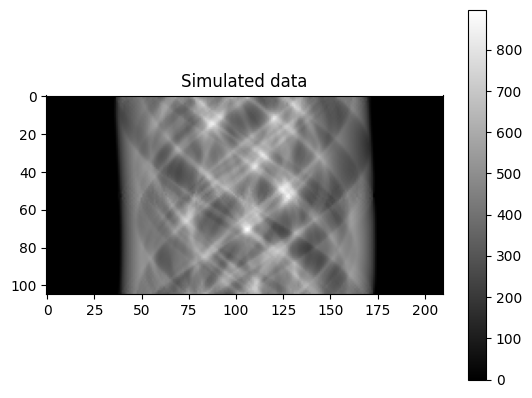

In [18]:
order = 0
x_dr = Float(x_th.reshape(-1))
fp = xtk.xrt_apply
bp = xtk.xrt_adjoint

y_dr = xtk.xrt_apply(ray_spec, knot_spec, order, x_dr)

plt.figure()
plt.imshow(th.asarray(y_dr).cpu().reshape(n_angles, -1), cmap='gray')
plt.colorbar()
plt.title("Simulated data")
plt.show()

### Perturb angles or offsets for calibration XP

In [19]:
if geom == "parallel":
    np_perturb_angles = np.linspace(0, np.pi, n_angles, endpoint=False) + np.random.normal(0, 0.01, n_angles)
    # np_perturb_angles = np.random.uniform(0, np.pi, n_angles)
    angles_perturbed = Float(np_perturb_angles)
    t_spec_dr, n_spec_dr = set_operators_parallel_beam_dr(
        N_side=v_shape[0],
        N_angle=n_angles,
        N_offset=2*v_shape[0],
        pitch=1.0,
        angles=angles_perturbed
    )
    ray_spec = (t_spec_dr, n_spec_dr)

if geom == "cone":
    ray_spec = cone_beam(
        sod=400.0,
        sdd=550.0,
        angles=dr.linspace(Float, 0, dr.pi, n_angles),
        detector_spec=DetectorSpec(1.5*v_shape[0], 2*v_shape[0]),
        delta = (0.0,0.0) 
    )

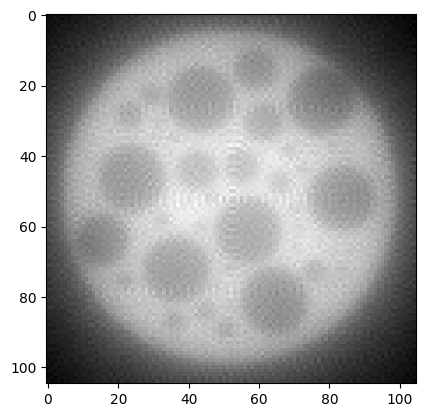

In [20]:
backproj = bp(ray_spec, knot_spec, order, y_dr)
plt.figure()
plt.imshow(th.asarray(backproj).cpu().reshape(v_shape), cmap='gray')


## Naive l2 reconstruction (both cone or parallel beam projections)

0 [65049.8]
100 [15.5099]
200 [13.4832]
300 [13.0458]
400 [12.824]
Final loss: [12.6978]


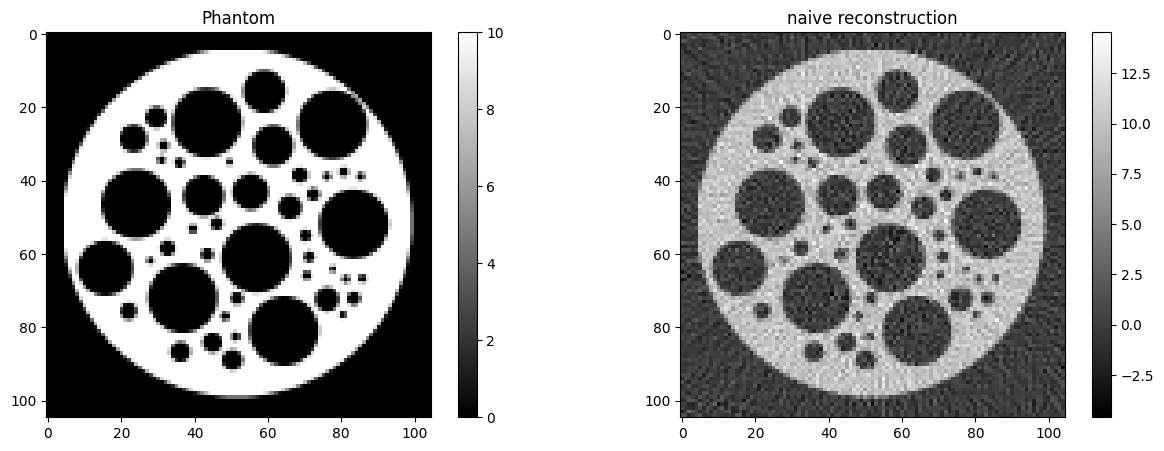

In [21]:
from drjit.opt import Adam, GradScaler, SGD

def loss(x_input):
    r = fp(ray_spec, knot_spec, order, x_input) - y_dr
    return 0.5*dr.mean(r*r)

x_init = dr.zeros_like(x_dr)
x = x_init
opt = Adam(lr=5, params={'x': x})
scaler = GradScaler()

for i in range(500):
    x[:] = Float(opt['x'])
    l = loss(x)                     
    dr.backward(scaler.scale(l))
    scaler.step(opt)
    if i % 100 == 0:
        print(i, l)

x_sol = opt['x']
print('Final loss:', loss(x_sol))

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.imshow(x_th.cpu().reshape(v_shape), cmap='gray')
plt.title('Phantom')
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(th.asarray(x_sol).cpu().reshape(v_shape), cmap='gray')
plt.title('naive reconstruction')
plt.colorbar()

0 [65049.8] [0.00580119]
100 [3.9132] [0.00148973]
200 [0.823945] [0.000477456]
300 [0.384001] [0.000177461]
400 [0.286577] [9.92941e-05]
[-2.17879]


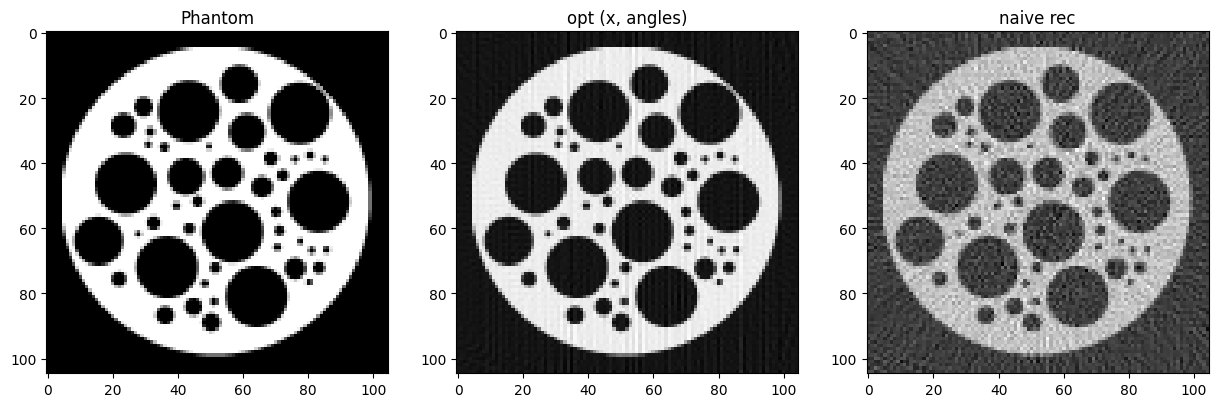

In [22]:
from drjit.opt import Adam, GradScaler, SGD

def loss(x_input, angles_input):
    t_spec_dr, n_spec_dr = set_operators_parallel_beam_dr(
        N_side=v_shape[0],
        N_angle=n_angles,
        N_offset=2*v_shape[0],
        pitch=1.0,
        angles=angles_input
    )

    ray_spec = (t_spec_dr, n_spec_dr)
    r = xtk.xrt_apply(ray_spec, knot_spec, order, x_input) - y_dr
    return 0.5*dr.mean(r**2)

x_init = dr.zeros_like(x_dr)
angles_init = dr.copy(angles_perturbed)

x = x_init
ang = angles_init

opt = Adam(lr=0., params={'x': x, 'v': ang})
# opt = SGD(lr=0., params={'x': x, 'v': ang})

scaler = GradScaler()
opt.set_learning_rate({'x': 3}) # 3 for adam
opt.set_learning_rate({'v': 0.0005}) # 0.0005 for adam

for i in range(500):
    x[:] = Float(opt['x'])
    ang[:] = Float(opt['v'])
    l = loss(x, ang) 
    dr.backward(scaler.scale(l))
    scaler.step(opt)
    if i % 100 == 0:
        print(i, l, 0.5*dr.sum((angles - ang)**2))

x_opt = opt['x']
angles_opt = opt['v']

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(x_th.cpu().reshape(v_shape), cmap='gray')
plt.title('Phantom')
plt.subplot(1,3,2)
plt.imshow(th.asarray(x_opt).cpu().reshape(v_shape), cmap='gray')
plt.title('opt (x, angles)') 
plt.subplot(1,3,3)
plt.imshow(th.asarray(x_sol).cpu().reshape(v_shape), cmap='gray')
plt.title('naive rec')

print(dr.sum(x_opt - x_sol))

## -----------------------------------------------------------------------------------

## Cone beam

In [26]:
from pixe_pyxu import *

dataset, dws = "bin2", 2
rx_pitch = (127e-3, 127e-3)  # 0.127 [mm] detector/receiver pitch (height, width)
froot = Path("/scratch/haouchat/pixe/M2EA99-000").expanduser()
fpath = froot / dataset

In [27]:
sod, sdd, v_shape, v_pitch, P = get_info(fpath)
v_shape = (v_shape[0], v_shape[2])
P = P[:, P.shape[1]//2, :]
P  = -np.log(P/P.max())
y_dr = Float(P.reshape(-1))
N_view, N_w = P.shape
size = 640
shift_cor = +0.293 

In [28]:
@th.enable_grad()
@dr.wrap(source='drjit', target='torch')
def setOperator_th(
    sod, sdd, N_view, N_h, N_w, v_pitch, rx_pitch, dws, shift_cor=0.0,
    *, dtype=th.float32, device=None
):
    """
    PyTorch (imported as th) version of setOperator.

    Returns
    -------
    t_spec: (N_view * N_h * N_w, 2) th.Tensor
    n_spec: (N_view * N_h * N_w, 2) th.Tensor
    """

    if device is None:
        device = th.device("cpu")

    # Shapes
    v_shape = (N_view, N_h, N_w)
    v_pitch = (1.0, 1.0, 1.0)

    # Unit conversions to mm
    rx_pitch = (rx_pitch[0] / 0.0319955, rx_pitch[1] / 0.0319955)
    shift_cor = shift_cor / 0.0319955
    sod = th.full((1,), sod / 0.0319955, dtype=dtype, device=device)
    sdd = sdd / 0.0319955

    # Detector extents
    rx_h = th.full((1,), rx_pitch[0] * dws * N_h, dtype=dtype, device=device)
    rx_w = rx_pitch[1] * dws * N_w

    # TX position
    tx_pos = th.cat((shift_cor, rx_h / 2.0, sod))

    # RX lower-left corner
    rx_ll = th.tensor(
        [-rx_w / 2.0 + shift_cor, 0.0, sod - sdd],
        dtype=dtype, device=device, requires_grad=True
    )

    # Meshgrid for detector pixel centers
    Y1d = (0.5 * rx_pitch[0] * dws) + th.arange(N_h, dtype=dtype, device=device) * (rx_pitch[0] * dws)
    X1d = (0.5 * rx_pitch[1] * dws) + th.arange(N_w, dtype=dtype, device=device) * (rx_pitch[1] * dws)
    Z1d = th.tensor([0.0], dtype=dtype, device=device)

    Y, X, Z = th.meshgrid(Y1d, X1d, Z1d, indexing="ij")

    rx_pos = rx_ll + th.cat([X, Y, Z], dim=-1)  # (N_h, N_w, 3)

    # Volume (kept for consistency, not returned)
    v_dim = th.tensor(v_shape, dtype=dtype, device=device) * th.tensor(v_pitch, dtype=dtype, device=device)
    v_center = th.tensor([0.0, rx_h / 2.0, 0.0], dtype=dtype, device=device)
    v_ll_vec = v_center - v_dim / 2.0

    # Ray parameterization
    n_spec = (rx_pos - tx_pos).reshape(-1, 3)#.requires_grad_(True)
    t_spec = tx_pos.unsqueeze(0).expand_as(n_spec)#.requires_grad_(True)

    # Rotations
    angle = -th.linspace(0, 2 * th.pi - 2*th.pi/N_view, steps=N_view, dtype=dtype, device=device)
    R = th.zeros((N_view, 3, 3), dtype=dtype, device=device)
    R[:, 0, 0] = th.cos(angle)
    R[:, 2, 2] = th.cos(angle)
    R[:, 2, 0] = th.sin(angle)
    R[:, 0, 2] = -th.sin(angle)
    R[:, 1, 1] = 1.0

    # Apply rotations
    n_spec = th.matmul(n_spec, R.transpose(1, 2)).reshape(-1, 3)
    t_spec = th.matmul(t_spec, R.transpose(1, 2)).reshape(-1, 3)

    # Keep only (x, z)
    n_spec = n_spec[:, [0, 2]]
    t_spec = t_spec[:, [0, 2]]

    # Not returned, but computed like original
    v_ll = (float(v_ll_vec[0].item()), float(v_ll_vec[2].item()))
    v_shape_xz = (v_shape[0], v_shape[2])
    v_pitch_xz = (1.0, 1.0)
    _ = (v_ll, v_shape_xz, v_pitch_xz)

    return t_spec.T, n_spec.T


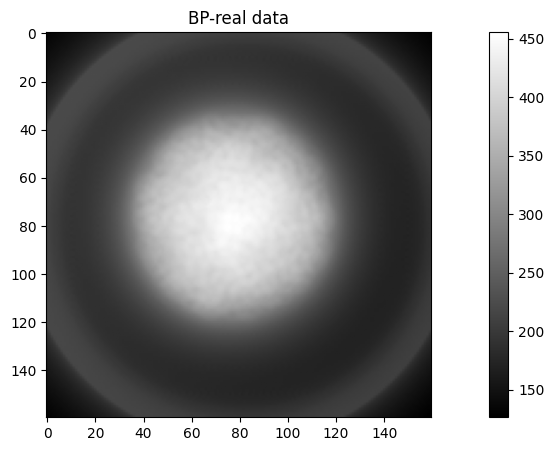

In [30]:
t_spec_th, n_spec_th = setOperator_th(sod, sdd, N_view, 1, N_w, v_pitch, rx_pitch, dws, shift_cor=th.tensor([0.],dtype=th.float32, device=device), dtype=th.float32, device=device)
ray_spec_th = (Array2f(t_spec_th), Array2f(n_spec_th))
knot_spec = xtk.UniformSpec(start=(-(size * 1.**2)/2, -(size * 1.**2)/2), step=(4., 4.), num=(size//4, size//4))
backproj_th = xtk.xrt_adjoint(ray_spec_th, knot_spec, 0, y_dr)

plt.figure(figsize=(15,5))
plt.imshow(th.asarray(backproj_th).cpu().reshape(size//4, size//4), cmap='gray')
plt.title('BP-real data')
plt.colorbar()

## Naive optimizazion (x only)

0 [0.0570186]
100 [0.00255412]
200 [0.00238852]
300 [0.00234397]
400 [0.00232489]
500 [0.00231473]
600 [0.00230858]
700 [0.00230453]
800 [0.0023017]
900 [0.00229965]


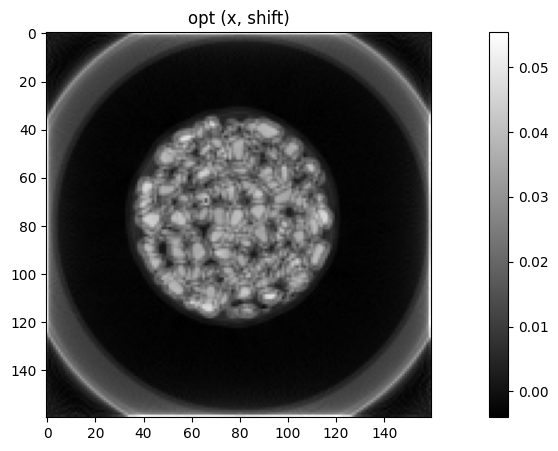

In [37]:
from drjit.opt import Adam, GradScaler, SGD
from drjit.cuda.ad import Float32

def loss(x_input):
    t_spec_th, n_spec_th = setOperator_th(sod, sdd, N_view, 1, N_w, v_pitch, rx_pitch, dws, shift_cor=th.tensor([-0.15],dtype=th.float32, device=device), dtype=th.float32, device=device)
    ray_spec = (Array2f(t_spec_th), Array2f(n_spec_th))
    r = xtk.xrt_apply(ray_spec, knot_spec, 0, x_input) - y_dr
    return 0.5*dr.mean(r**2)

x = dr.zeros_like(backproj_th)
dr.enable_grad(x)

# opt = Adam(lr=0., params={'x': x, 'v': shift})
opt = SGD(lr=0., params={'x': x})
scaler = GradScaler()

opt.set_learning_rate({'x': 5}) # 5 for adam
for i in range(1000):
    x[:] = Float(opt['x'])
    l = loss(x) 
    dr.backward(scaler.scale(l))
    scaler.step(opt)
    if i % 100 == 0:
        print(i, l)

x_opt = opt['x']

plt.figure(figsize=(15,5))
plt.imshow(th.asarray(x_opt).cpu().reshape((size//4, size//4)), cmap='gray')
plt.title('opt (x, shift)')
plt.colorbar()


## Shift correction optimization

/tmp/ipykernel_7565/1125828460.py:37: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  rx_ll = th.tensor(


0 [0.0570186] [0]
100 [0.00249796] [-0.234982]
200 [0.00222568] [-0.265303]
300 [0.00212993] [-0.275155]
400 [0.00208368] [-0.278487]
500 [0.00205837] [-0.279621]
600 [0.00204332] [-0.280533]
700 [0.00203381] [-0.281135]
800 [0.00202751] [-0.281465]
900 [0.00202317] [-0.281915]


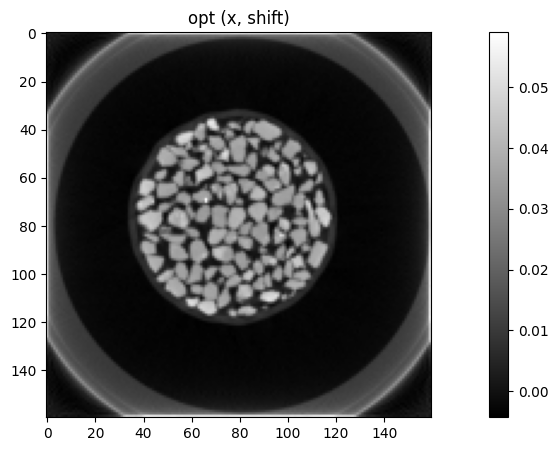

In [31]:
from drjit.opt import Adam, GradScaler, SGD
from drjit.cuda.ad import Float32

def loss(x_input, shift_input):
    t_spec_th, n_spec_th = setOperator_th(sod, sdd, N_view, 1, N_w, v_pitch, rx_pitch, dws, shift_cor=shift_input, dtype=th.float32, device=device)
    ray_spec = (Array2f(t_spec_th), Array2f(n_spec_th))
    r = xtk.xrt_apply(ray_spec, knot_spec, 0, x_input) - y_dr
    return 0.5*dr.mean(r**2)

x = dr.zeros_like(backproj_th)
shift = Float32(0)
dr.enable_grad(shift)
dr.enable_grad(x)

# opt = Adam(lr=0., params={'x': x, 'v': shift})
opt = SGD(lr=0., params={'x': x, 'v': shift})
scaler = GradScaler()

opt.set_learning_rate({'x': 5}) # 5 for adam
opt.set_learning_rate({'v': 5}) # 0.005 for adam
for i in range(1000):
    x[:] = Float(opt['x'])
    shift = Float32(opt['v'])
    l = loss(x, shift) 
    dr.backward(scaler.scale(l))
    scaler.step(opt)
    if i % 100 == 0:
        print(i, l, opt['v'])

x_opt = opt['x']
shift_opt = opt['v']

plt.figure(figsize=(15,5))
plt.imshow(th.asarray(x_opt).cpu().reshape((size//4, size//4)), cmap='gray')
plt.title('opt (x, shift)')
plt.colorbar()


## -----------------------------------------------------------------------